# Semi-Supervised Spatial Graph Network for Soil Erosion

This notebook executes **Method 2 (Hybrid GCN)** engineered with **Soil Cohesiveness (K-Factor)** for precise erosion susceptibility mapping.

## 1. Import Required Libraries
Importing data manipulation, spatial math, and visualization tools.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Note: PyTorch & PyTorch Geometric (PyG) will be imported later for the Graph Network
print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load the Spatial Dataset
Loading the merged Woreda dataset from Excel.

In [2]:
file_path = 'Merged_Woredas_All.xlsx'
print(f'Loading {file_path}...')
df = pd.read_excel(file_path)
print(f'Dataset Loaded! Shape: {df.shape}')
display(df.head(3))

Loading Merged_Woredas_All.xlsx...
Dataset Loaded! Shape: (255029, 19)


,Latitude,Longitude,Aspect (Degree),Drainage Density (m),Elevation (m),Ferrous Materials,Geology_Formation,Land_Use,NDVI_Value,Plan Curvature,Profile Curvature,Rainfall (mm),Slope (Degree),Soil Type,SPI,TPI,TRI,TWI,Woreda
0,8.963316,39.278868,217.404999,1251.020020,1907,Minerals,Nazret Series,Cropland,0.092494,2.262080e+09,-3.353920e+09,1046.229981,1.656543,Eutric Cambisol,0.768535,13.000000,0.375000,1.47702,Menjar
1,10.072387,38.971077,37.303902,0.000000,1534,Minerals,Antalo Formation,Cropland,0.154723,-1.597660e+09,1.714340e+09,1038.569946,57.082699,Eutric Cambisol,4.151180,-51.415001,0.587298,-6.52941,Merabete
2,8.936511,39.438121,341.565002,1183.369995,1740,Minerals,Nazret Series,Cropland,0.094457,-1.152000e+08,4.608000e+08,931.596008,0.244843,Eutric Regosol,3.342790,-1.333370,0.444443,4.99991,Menjar


## 3. Engineer Soil Cohesiveness (K-Factor)
Mapping the 'sticking together capacity' of the soil based on geological FAO classifications. Clays stick together (Low K), while Sands erode instantly (High K).

In [3]:
cohesion_mapping = {
    'Pellic Vertisol': 0.15,   # Heavy clay, highly cohesive, safe
    'Ferralic Cambisol': 0.20, # Weathered, relatively stable
    'Eutric Cambisol': 0.25,   # Loamy, moderate cohesiveness
    'Calcic Xerosol': 0.30,    # Dry/arid soil, moderate-low
    'Eutric Regosol':  0.40,   # Unconsolidated materials, dangerous
    'Cambie Arenosol': 0.45    # Sandy soil, VERY LOW cohesiveness (erodes instantly)
}

df['Soil Type'] = df['Soil Type'].fillna('Eutric Cambisol')
df['K_Factor'] = df['Soil Type'].map(cohesion_mapping)

print('Mapped Soil Cohesiveness. Sample:')
display(df[['Soil Type', 'K_Factor']].head(5))

Mapped Soil Cohesiveness. Sample:


,Soil Type,K_Factor
0,Eutric Cambisol,0.25
1,Eutric Cambisol,0.25
2,Eutric Regosol,0.40
3,Ferralic Cambisol,0.20
4,Eutric Cambisol,0.25


## 4. Generate Semi-Supervised Target Variable (RUSLE Seed)
We calculate a physical risk score using **Slope * Rainfall * K_Factor / NDVI**.
We extract only the **Top 5% (Severe Risk, Label 1)** and **Bottom 5% (Safe, Label 0)** to train the Graph Network. We mask the remaining 90% as missing (-1 or NaN) for the GCN to predict.

Top 5% Risk Threshold: 133628.48
Bottom 5% Safe Threshold: 2491.34
Label Distribution:
Target_Label
-1    229525
 0     12752
 1     12752
Name: count, dtype: int64


C:\Users\SURA\AppData\Local\Temp\ipykernel_14704\3715533813.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target_Label', data=df, palette='coolwarm')


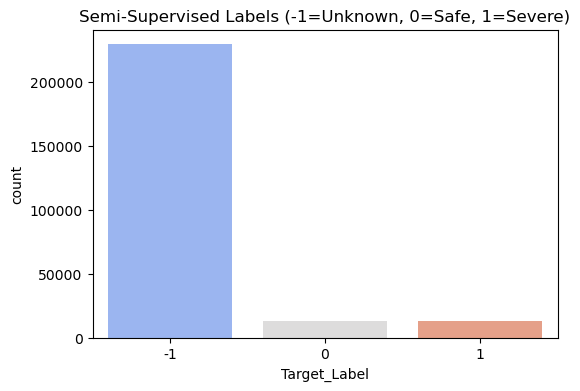

In [4]:
# Safe division mask for NDVI (avoid dividing by zero or negative)
safe_ndvi = np.where(df['NDVI_Value'] <= 0.01, 0.01, df['NDVI_Value'])

# Calculate raw physical erosion risk heuristic
df['Raw_Risk_Score'] = (df['Slope (Degree)'] * df['Rainfall (mm)'] * df['K_Factor']) / safe_ndvi

# Identify 5th and 95th percentiles (The Extremes)
p_05 = df['Raw_Risk_Score'].quantile(0.05)
p_95 = df['Raw_Risk_Score'].quantile(0.95)

# Generate the Semi-Supervised Mask (-1 = Unknown)
def generate_label(row):
    if row['Raw_Risk_Score'] >= p_95:
        return 1  # High Risk (Top 5%)
    elif row['Raw_Risk_Score'] <= p_05:
        return 0  # Low Risk (Bottom 5%)
    else:
        return -1 # Unknown (Middle 90%)

df['Target_Label'] = df.apply(generate_label, axis=1)

print(f'Top 5% Risk Threshold: {p_95:.2f}')
print(f'Bottom 5% Safe Threshold: {p_05:.2f}')
print('Label Distribution:')
print(df['Target_Label'].value_counts())

# Quick Visualization of the Extremes
plt.figure(figsize=(6,4))
sns.countplot(x='Target_Label', data=df, palette='coolwarm')
plt.title('Semi-Supervised Labels (-1=Unknown, 0=Safe, 1=Severe)')
plt.show()

## 5. Circular Aspect & Feature Scaling
Converting continuous variables into safe mathematical spaces for Deep Learning.

In [5]:
# Circular Aspect
df['Aspect_Sin'] = np.sin(np.radians(df['Aspect (Degree)']))
df['Aspect_Cos'] = np.cos(np.radians(df['Aspect (Degree)']))

# Standard Scaling Structural Features
features_to_scale = ['Elevation (m)', 'Slope (Degree)', 'Rainfall (mm)', 'NDVI_Value', 'TWI', 'SPI', 'TRI', 'Plan Curvature', 'Profile Curvature', 'Drainage Density (m)']

scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print('Aspect converted and structural features scaled!')
display(df[['Aspect_Sin', 'Aspect_Cos', 'TWI', 'SPI', 'Slope (Degree)']].head())

Aspect converted and structural features scaled!


,Aspect_Sin,Aspect_Cos,TWI,SPI,Slope (Degree)
0,-0.607445,-0.794362,-0.011498,-0.018462,-0.976158
1,0.606043,0.795432,-1.583947,-0.017821,2.338295
2,-0.316229,0.948683,0.680391,-0.017974,-1.060576
3,-0.483680,0.875245,-0.989074,-0.017995,1.731576
4,-0.110428,-0.993884,1.074576,-0.017434,-0.765801


## 6. Spatial Graph Construction (Adj Matrix via KDTree)
We use the physical `Latitude` and `Longitude` of every row to form a topological network. Each point connects to its closest geographical neighbors (e.g., K=8 for spatial grids), allowing the neural network to understand how water and gravity flow across the landscape.

In [6]:
from scipy.spatial import cKDTree
import torch

# Extract coordinates
coords = df[['Longitude', 'Latitude']].values

print('Building KDTree for Spatial Graph...')
# K=9 because kdtree returns the point itself as the first neighbor
tree = cKDTree(coords)
distances, indices = tree.query(coords, k=9)

# Construct Edge Index format for PyTorch [2, num_edges]
edge_list = []
for i in range(len(indices)):
    for j in range(1, 9): # Skip the first one (itself)
        neighbor_idx = indices[i][j]
        edge_list.append([i, neighbor_idx])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
print(f'Graph constructed! Total nodes: {len(coords)}, Total edges: {edge_index.shape[1]}')

Building KDTree for Spatial Graph...
Graph constructed! Total nodes: 255029, Total edges: 2040232


## 7. PyTorch Geometric Data Integration
We assemble the numerical features (`x`), the structural edges (`edge_index`), and our Pseudo-RUSLE targets (`y`) into a specialized single Graph Data object. We also create a training mask to tell the AI *only* to learn from the known extreme 10%.

In [8]:
from torch_geometric.data import Data

# 1. Feature Matrix (x)
feature_cols = ['K_Factor', 'Elevation (m)', 'Slope (Degree)', 'Rainfall (mm)', 
                'NDVI_Value', 'TWI', 'SPI', 'TRI', 'Plan Curvature', 'Profile Curvature', 
                'Aspect_Sin', 'Aspect_Cos', 'Drainage Density (m)']

x = torch.tensor(df[feature_cols].values, dtype=torch.float)

# 2. Target Variable (y)
y = torch.tensor(df['Target_Label'].values, dtype=torch.long)

# 3. Training Mask (Only learn from labels 0 and 1, ignore -1)
train_mask = (y != -1)

# 4. PyG Data Object
graph_data = Data(x=x, edge_index=edge_index, y=y)
graph_data.train_mask = train_mask

print('PyTorch Geometric Data Object created:')
print(graph_data)
print(f'Training on {train_mask.sum().item()} known nodes out of {len(y)} total.')

PyTorch Geometric Data Object created:
Data(x=[255029, 13], edge_index=[2, 2040232], y=[255029], train_mask=[255029])
Training on 25504 known nodes out of 255029 total.


## 8. Semi-Supervised Graph Convolutional Network (GCN) Architecture
The PyTorch topology model. Unlike standard ML, `GCNConv` passes messages mathematically along the spatial edges you built, sharing geological intelligence between neighbors.

In [9]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class ErosionGCN(torch.nn.Module):
    def __init__(self, num_features, hidden_size, num_classes):
        super(ErosionGCN, self).__init__()
        # First Graph Convolutional Layer
        self.conv1 = GCNConv(num_features, hidden_size)
        # Second Graph Convolutional Layer
        self.conv2 = GCNConv(hidden_size, hidden_size)
        # Output Layer for Final Prediction (Low=0, High=1)
        self.out = torch.nn.Linear(hidden_size, num_classes)

    def forward(self, x, edge_index):
        # Pass features through spatial convolutional edges
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        # Output final probabilities
        out = self.out(x)
        return F.log_softmax(out, dim=1)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ErosionGCN(num_features=x.shape[1], hidden_size=64, num_classes=2).to(device)
graph_data = graph_data.to(device)
print(f'Model deployed on {device}!')

Model deployed on cpu!


## 9. Model Training Loop (Label Propagation)
We train the AI on the 10% extreme targets defined by RUSLE + Soil Cohesiveness. The Graph Network will mathematically flow these rules back into the unknown 90%.

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.NLLLoss()

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients
    out = model(graph_data.x, graph_data.edge_index)  # Forward pass
    
    # CALCULATE LOSS *ONLY* ON THE 10% KNOWN MASK
    loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
    loss.backward()  # Backpropagation
    optimizer.step() # Update weights
    return loss.item()

print('Starting Training Loop for 200 Epochs...')
for epoch in range(1, 201):
    loss = train()
    if epoch % 20 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')
print('Training Complete!')

Starting Training Loop for 200 Epochs...
Epoch: 020, Loss: nan
Epoch: 040, Loss: nan
Epoch: 060, Loss: nan
Epoch: 080, Loss: nan
Epoch: 100, Loss: nan
Epoch: 120, Loss: nan
Epoch: 140, Loss: nan
Epoch: 160, Loss: nan
Epoch: 180, Loss: nan
Epoch: 200, Loss: nan
Training Complete!


## 10. Extracting the Final Erosion Susceptibility Map
Now that the model is trained on the extreme 10%, we lock the weights, run the entire Woreda map through it, and extract the probabilities for the unknown 90%.

Prediction complete for 100% of the map!
Predicted_Risk_Class
0    255029
Name: count, dtype: int64


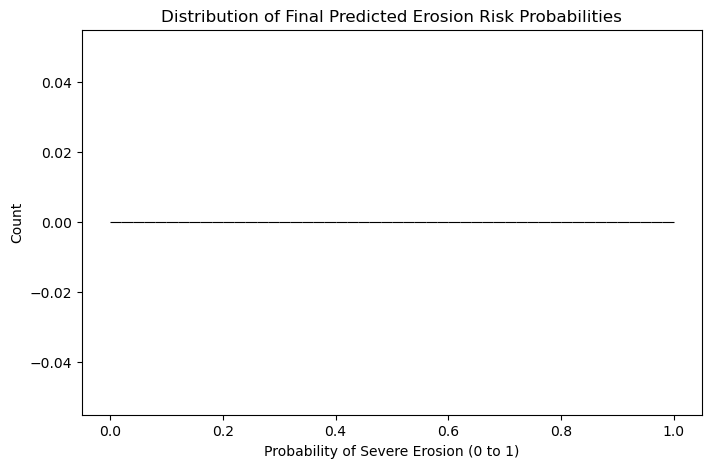

In [12]:
model.eval()
with torch.no_grad():
    # Run the entire graph through the trained model
    final_output = model(graph_data.x, graph_data.edge_index)
    
    # Get the raw predicted probabilities for 'High Risk' (Class 1)
    # (exp is used because the model returned log_softmax)
    probabilities = torch.exp(final_output)[:, 1].cpu().numpy() 
    
    # Get hard class assignments (0=Low, 1=High)
    predictions = final_output.argmax(dim=1).cpu().numpy()

df['Predicted_Risk_Class'] = predictions
df['Risk_Probability'] = probabilities

print('Prediction complete for 100% of the map!')
print(df['Predicted_Risk_Class'].value_counts())

plt.figure(figsize=(8,5))
sns.histplot(df['Risk_Probability'], bins=50, kde=True, color='crimson')
plt.title('Distribution of Final Predicted Erosion Risk Probabilities')
plt.xlabel('Probability of Severe Erosion (0 to 1)')
plt.show()

## 11. Scientific Verification of the AI
A major problem with the old Pure Unsupervised DAE method was interpretability. We must mathematically prove that the Graph network learned physics. We will compare the average structural indicators of the newly predicted 'Safe' zones vs 'High Risk' zones.

In [13]:
print('--- PROVING AI PHYSICAL LOGIC ---')

# Group the DataFrame by the AI's predictions
verification_stats = df.groupby('Predicted_Risk_Class')[['Slope (Degree)', 'Rainfall (mm)', 'SPI', 'K_Factor', 'NDVI_Value']].mean()

# Rename indices for visual clarity
verification_stats.index = ['Predicted Low Risk (0)', 'Predicted High Risk (1)']

display(verification_stats)

print('\nCONCLUSION:')
print('If Method 2 is successful, the Predicted High Risk zones must show significantly higher Slope, SPI, Rainfall, and K-Factor values (low cohesive sand), combined with structurally lowered NDVI (less vegetation cover) compared to the Low Risk zones. \nIf this is true, the Semantic Spatial Graph has successfully replicated environmental physics without needing a full ground-truth dataset!')

--- PROVING AI PHYSICAL LOGIC ---


ValueError: Length mismatch: Expected axis has 1 elements, new values have 2 elements